In [2]:
import numpy as np
import matplotlib.pylab as pl
import ipywidgets as ipw
%matplotlib inline
t = np.linspace(0,2*np.pi,100)
eps = np.exp(1j*t)

@ipw.interact(eta=(0,0.5,0.02))
def plot_stress_strain(eta=0.02):
    sigma = (1+1j*eta)*eps
    pl.plot(np.real(eps),np.real(sigma))
    pl.xlabel(r'$\epsilon/\hat\epsilon$')
    pl.ylabel(r'$\sigma/\hat\sigma$');
    pl.axis('equal')

interactive(children=(FloatSlider(value=0.02, description='eta', max=0.5, step=0.02), Output()), _dom_classes=…

In [3]:
import sympy as sy
eta, E, rho, om = sy.symbols("eta E rho omega", positive=True)
# complex modulus
E_ = E*(1+sy.I*eta)
# wave number L-waves
kL = om*sy.sqrt(rho/E)
# substitue complex modulus and find approximation using a series
kL_ = sy.series(kL.subs(E,E_),eta,n=2)
# show factor to apply to lossless case 
display(kL_,sy.simplify(kL_/kL))

omega*sqrt(rho)/sqrt(E) - I*eta*omega*sqrt(rho)/(2*sqrt(E)) + O(eta**2)

1 - I*eta/2 + O(eta**2)

In [4]:
m1, I = sy.symbols("m' I", positive=True)
# wave number bending waves
kB = sy.sqrt(om)*sy.root(m1/(E*I),4)
kB_ = sy.series(kB.subs(E,E_),eta,n=2)
display(kB_,sy.simplify(kB_/kB))

m'**(1/4)*sqrt(omega)/(E**(1/4)*I**(1/4)) - I*eta*m'**(1/4)*sqrt(omega)/(4*E**(1/4)*I**(1/4)) + O(eta**2)

1 - I*eta/4 + O(eta**2)

In [5]:
import numpy as np
import matplotlib.pyplot as pl
import ipywidgets as ipw
%matplotlib inline

@ipw.interact(t=(0,10,0.1),eta_=(0,0.2,0.02))
def plot_xiy_halfbeam(t=0,eta_=0):
    x = np.arange(0,50,0.5)
    # assume amplitudes=1, kB=1, omega=1
    xi = (np.exp(-1j*(1-0.25j*eta_)*x)+np.exp(-1*(1-0.25j*eta_)*x))*np.exp(1j*t)
    # plot everything
    pl.plot(x,xi.real,label=r'$\xi_y$')
    pl.ylim(-3,3)
    pl.xlabel(r'$x$')
    pl.legend()

interactive(children=(FloatSlider(value=0.0, description='t', max=10.0), FloatSlider(value=0.0, description='e…

In [6]:
E1, E2, mu1, mu2, h1, h2 = sy.symbols("E_1 E_2 mu_1 mu_2 h_1 h_2",
                                      positive=True)
y, y0 = sy.symbols("y y_0",positive=True)
# integrate over thickness
i1 = sy.integrate(E1*(y-y0)/(1-mu1**2),(y,0,h1)) # base layer
i2 = sy.integrate(E2*(y-y0)/(1-mu2**2),(y,h1,h1+h2)) # damping layer
# sum of both = 0
y0_ = sy.solve(i1+i2,y0)[0]
display(sy.Eq(y0,y0_))
# assume mu1 = mu2
y0_ = y0_.subs(mu1,mu2).simplify()
display(sy.Eq(y0,y0_))

Eq(y_0, (E_1*h_1**2*mu_2**2/2 - E_1*h_1**2/2 + E_2*h_1*h_2*mu_1**2 - E_2*h_1*h_2 + E_2*h_2**2*mu_1**2/2 - E_2*h_2**2/2)/(E_1*h_1*mu_2**2 - E_1*h_1 + E_2*h_2*mu_1**2 - E_2*h_2))

Eq(y_0, (E_1*h_1**2/2 + E_2*h_1*h_2 + E_2*h_2**2/2)/(E_1*h_1 + E_2*h_2))

In [7]:
eta1, eta2, B1 = sy.symbols("eta_1 eta_2 B'",positive=True)
# integrate over thickness to get bending stiffness
i1 = sy.integrate(E1*(1+sy.I*eta1)*(y-y0)**2,(y,0,h1))
i2 = sy.integrate(E2*(1+sy.I*eta2)*(y-y0)**2,(y,h1,h1+h2))
B1_ = i1+i2
# display complex bending stiffness
display(sy.Eq(B1,B1_.simplify()))
# display just the real part
display(sy.Eq(B1,sy.collect(sy.re(B1_),(E1,E2))))

Eq(B', E_1*h_1**3*(I*eta_1 + 1)/3 - E_1*h_1**2*y_0*(I*eta_1 + 1) + E_1*h_1*y_0**2*(I*eta_1 + 1) - E_2*h_1**3*(I*eta_2 + 1)/3 + E_2*h_1**2*y_0*(I*eta_2 + 1) - E_2*h_1*y_0**2*(I*eta_2 + 1) + E_2*y_0**2*(h_1 + h_2)*(I*eta_2 + 1) - E_2*y_0*(h_1 + h_2)**2*(I*eta_2 + 1) + E_2*(h_1 + h_2)**3*(I*eta_2 + 1)/3)

Eq(B', E_1*(h_1**3/3 - h_1**2*y_0 + h_1*y_0**2) + E_2*(-h_1**3/3 + h_1**2*y_0 - h_1*y_0**2 + y_0**2*(h_1 + h_2) - y_0*(h_1 + h_2)**2 + (h_1 + h_2)**3/3))

In [8]:
# assume E1>>E2 and compute B1
display(sy.Eq(B1,sy.limit(sy.re(B1_).subs(y0,y0_),E2,0)))
# assume eta1<<eta2 and E1>>E2 and compute eta 
eta_ = sy.limit(sy.im(B1_),eta1,0)/sy.limit(sy.re(B1_),E2,0)
eta_ = eta_.subs(y0,y0_).simplify()
display(sy.Eq(eta,eta_))

Eq(B', E_1*h_1**3/12)

Eq(eta, E_2*eta_2*h_2*(3*E_1**2*h_1**4 + 6*E_1**2*h_1**3*h_2 + 4*E_1**2*h_1**2*h_2**2 + 2*E_1*E_2*h_1*h_2**3 + E_2**2*h_2**4)/(E_1*h_1*(E_1**2*h_1**4 + 2*E_1*E_2*h_1**3*h_2 + 4*E_2**2*h_1**2*h_2**2 + 6*E_2**2*h_1*h_2**3 + 3*E_2**2*h_2**4)))

In [9]:
numerical_values = {E1: 210e9, E2: 210e6, eta1: 0.001, eta2: 0.5, h1: 0.001, h2: 0.005}  # Example values
eta_numeric = eta_.evalf(subs=numerical_values)
print(eta_numeric)

0.328940790935348


0.199013484764729


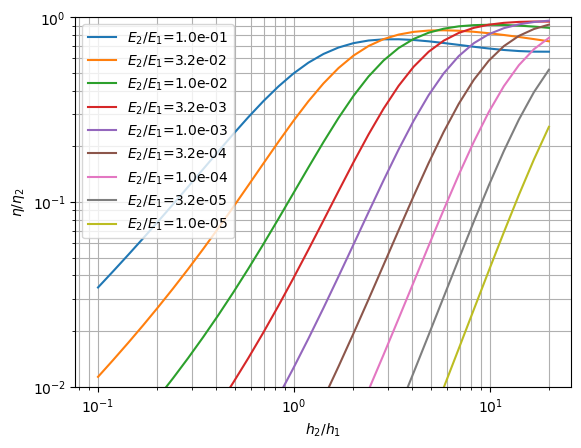

In [10]:
# because we can, we do not make any assumptions in the derivation here
eta_ = (sy.im(B1_)/sy.re(B1_)).subs(y0,y0_)
numerical_values = {E1: 210e9, E2: 210e6, eta1: 0.001, eta2: 0.5, h1: 0.001, h2: 0.005}  # Example values
eta_numeric = eta_.evalf(subs=numerical_values)

print(eta_numeric)
# make a numeric function
eta__ = sy.lambdify((E1,E2,h1,h2,eta1,eta2),eta_)
h2_ = np.logspace(-1,1.3,31)
for E2_ in np.logspace(-1,-5,9):
    pl.loglog(h2_,eta__(1,E2_,1,h2_,0,1),label=r"$E_2/E_1$=%.1e" % E2_)
pl.ylim(1e-2,1)
pl.legend()
pl.grid(which='both')
pl.xlabel(r"$h_2/h_1$")
pl.ylabel(r"$\eta/\eta_2$");